# 10 — Mini-Proyek: Laporan EDA Otomatis
Kita akan menggabungkan semua keterampilan eksplorasi data menjadi **satu fungsi reusable**.

Bayangkan: setiap kali menerima dataset baru, kamu cukup memanggil satu fungsi dan langsung mendapat ringkasan lengkap. Inilah cara profesional bekerja — membangun **pipeline EDA** yang bisa dipakai berulang.

> 🎯 **Tujuan Pembelajaran**
> - Merangkum langkah-langkah EDA menjadi **fungsi Python** (`ringkas_eda`).
> - Menghasilkan ringkasan otomatis: shape, dtypes, missing, statistik, top kategori.
> - Menerapkan fungsi pada data **Telco Customer Churn**.
> - Menarik insight bisnis dari hasil ringkasan.

## 📊 Tentang Dataset

Kita memakai **Telco Customer Churn**, data 7043 pelanggan perusahaan telekomunikasi,
termasuk layanan yang dipakai dan apakah mereka berhenti berlangganan (*churn*).

- **Sumber:** [Kaggle — blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
- **Jumlah data:** 7043 baris × 21 kolom

| Kolom (penting) | Arti |
|-------|------|
| `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Profil demografis pelanggan |
| `tenure` | Lama berlangganan (bulan) |
| `Contract` | Jenis kontrak (Month-to-month / One year / Two year) |
| `MonthlyCharges` | Tagihan bulanan |
| `TotalCharges` | Total tagihan (kadang kosong → perlu dibersihkan) |
| `Churn` | Target: apakah pelanggan berhenti (Yes/No) |

## 1. Import Library

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset Telco Churn

In [25]:
!pip install -q kaggle
!kaggle datasets download -d blastchar/telco-customer-churn

#unzip
!unzip -q telco-customer-churn.zip

#Load
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)
replace WA_Fn-UseC_-Telco-Customer-Churn.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Explorasi sederhana

In [26]:
print("Bentuk data = ", df.shape)

df.info()

Bentuk data =  (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

Interpretasi :

- Terdapat 7043 Baris dan 21 kolom
- Terlihat tidak ada nilai yang hilang
- Data didominasi dengan nilai string
- Data Numerik terbatas

## Pembersihan Data
Korversi kolom (Total Charge) dari string ke numerical, jika terdapat missing value akan diubah menjadi NaN, dan langsung ditangani

In [27]:
# Konversi TotalCharge ke Num; Nilai tidak valid diubah jadi NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing Total Chargers setelah Konversi:", df['TotalCharges'].isna().sum())

Missing Total Chargers setelah Konversi: 11


In [28]:
#Baris kosong ini adalah pelanggan baru dengan tenure = 0, ganti dengan nilai 0
df['TYotalCharges'] = df['TotalCharges'].fillna(0)

In [29]:
df = df.drop(columns="customerID")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Interpretasi :
- Terdapat 11 NaN, di TotalCharges, di indikasika nilai ini adalah 0, berasal dari Tenure dengan Tenure 0, yang mengidikasikan adanya pelanggan baru, ubah value NaN ini dengan nilai 0.

- Buang kolom CustomerID


## Membangun Fungsi EDA Otomatis

In [34]:
def ringkas_eda(data: pd.DataFrame, top_n: int = 3) -> pd.DataFrame:
    """Mencetak Ringkasan EDA Otomatis dan mengembalikan tabel info Kolom"""
    print("="*55)
    print("Ringkasan EDA Otomatis")
    print("="*55)
    print(f"jumlah baris: {data.shape[0]}")
    print(f"jumlah kolom: {data.shape[1]}")
    print(f"baris duplikat: {data.duplicated().sum()}")


    #Tabel ringkas per kolom: tipe, missing, jumlah nilai unik
    info = pd.DataFrame({
        "tipe data": data.dtypes.astype(str),
        "missing": data.isna().sum(),
        "missing %":(data.isnull().mean()*100).round(1),
        "unik": data.nunique()
    })

    print("\nInfo Kolom:")
    print(info)

    #Statistik Kolom Numerik
    num = data.select_dtypes(include=np.number)
    if not num.empty:
        print("\nStatistik Kolom Numerik:")
        print(num.describe())


    #Statistik Kolom Categorical
    cat = data.select_dtypes(exclude=np.number)
    if not cat.empty:
        print("\nStatistik Kolom Kategorik:")
        for kol in cat.columns:
          top = data[kol].value_counts().head(top_n)
          print(f"\nTop {top_n} {kol}:")
          print(top)

    return info


Interpretasi :
- Fungsi ini menerima DataFrame apa pun dan otomatis menampilkan:
ukuran data, duplikat, info tiap kolom (tipe/missing/unik), statistik numerik, dan kategori teratas tiap kolom teks. Sangat reusable untuk dataset apa pun.

##Menjalankan Fungsi pada Data Telco

In [35]:
info = ringkas_eda(df)

Ringkasan EDA Otomatis
jumlah baris: 7043
jumlah kolom: 20
baris duplikat: 22

Info Kolom:
                 tipe data  missing  missing %  unik
gender              object        0        0.0     2
SeniorCitizen        int64        0        0.0     2
Partner             object        0        0.0     2
Dependents          object        0        0.0     2
tenure               int64        0        0.0    73
PhoneService        object        0        0.0     2
MultipleLines       object        0        0.0     3
InternetService     object        0        0.0     3
OnlineSecurity      object        0        0.0     3
OnlineBackup        object        0        0.0     3
DeviceProtection    object        0        0.0     3
TechSupport         object        0        0.0     3
StreamingTV         object        0        0.0     3
StreamingMovies     object        0        0.0     3
Contract            object        0        0.0     3
PaperlessBilling    object        0        0.0     2
PaymentM

Interpretasi :
-  Dari output: tidak ada missing tersisa, `tenure` berkisar 0–72 bulan,
`MonthlyCharges` rata-rata ~$65, dan mayoritas pelanggan memakai kontrak `Month-to-month`.

- Semua ringkasan dihasilkan hanya dengan satu panggilan fungsi.


## EDA menggunakan Visualisasi


### a) Proporsi Churn ( Countplot )

/tmp/ipykernel_1525/3492440455.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette='mako')


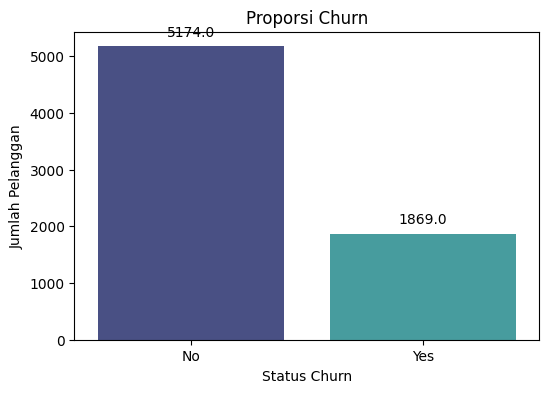

Churn
No     0.73
Yes    0.27
Name: proportion, dtype: float64


In [42]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn", palette='mako')
plt.title("Proporsi Churn")
plt.xlabel("Status Churn")
plt.ylabel("Jumlah Pelanggan")
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height()}', (p.get_x()+p.get_width()/2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

print(df['Churn'].value_counts(normalize=True).round(2))

Interpretasi :
- Sebanyak 1869 pelanggan terindikasi Churn, dan 5174 pelanggan masih bertahan
- Proporsinya sebanyak 27 % Churn, dan 73 yang retention
- Gunakan pendekatan yang masih menggunakan media promosi dan diskon untuk pelanggan yang terindikasi Churn

### b) Churn berdasarakan Jenis Kontrak ( groupped Bar )

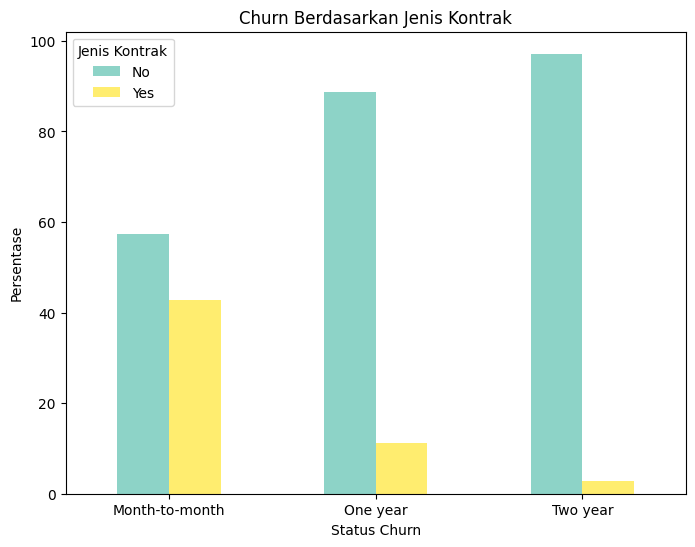

In [68]:
ch_kontrak = pd.crosstab(df['Contract'], df['Churn'], normalize="index")*100
ch_kontrak.plot(kind="bar", figsize=(8,6), colormap="Set3")
plt.title("Churn Berdasarkan Jenis Kontrak")
plt.xlabel("Status Churn")
plt.ylabel("Persentase")
plt.xticks(rotation=0)
plt.legend(title="Jenis Kontrak")
plt.show()

Interpretasi :
- Status pelanggan yang berlangganan Bulan ke Bulan, Memilik tingkat Churn (~44%), lebih tinggi daripada pelanggan 1 atau 2 tahun lebih
-Saran tindakan optimalisasi mengikat pelanggan dengan paket berlangganan lebih murah dengan status berlangganan tahunan

### c)Distribusi Tenure berdasarkan churn ( histogram )

/tmp/ipykernel_1525/1382876855.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Status Churn")


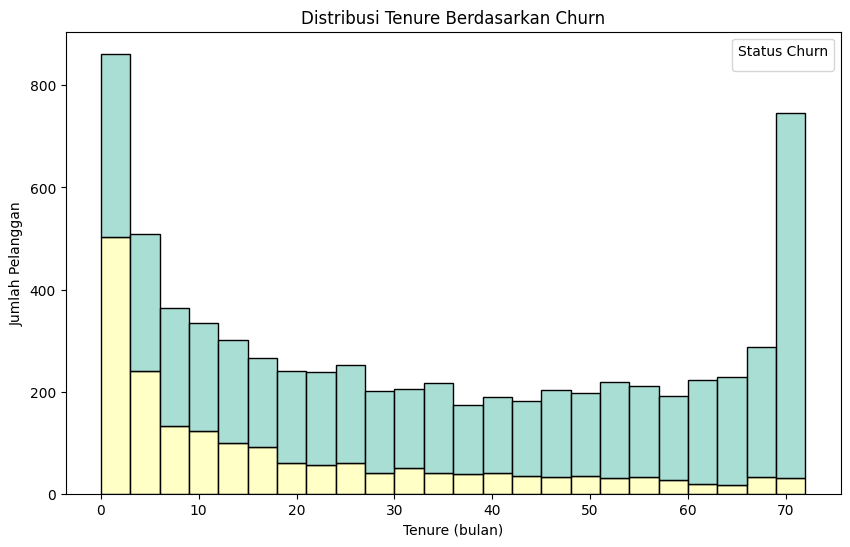

In [77]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="tenure",bins=24, hue="Churn", multiple="stack", palette="Set3")
plt.title("Distribusi Tenure Berdasarkan Churn")
plt.xlabel("Tenure (bulan)")
plt.ylabel("Jumlah Pelanggan")
plt.legend(title="Status Churn")
plt.show()

Interpretasi :
- Jumlah Bin 24, Total Tenure 72, 1 Bin = 3 Bulan, ini untuk mempermudah interpretasi saja
- Tingkat Churn tertinggi ada di Bin 1-5. yang menandakan 1-15 bulan adalah fase krusial, untuk customer menilai layanan, apakah mereka puas dengan layanan yang diberikan,
- Tingkat Churn mulai berkurang di Bin ke 6 hingga seterusnya. menandakan pelanggan mulai puas dengan layanan dan memasukin masa langgangan tahun ke 2
- Bin awal atau bulan bulan awal berlanggangan adalah masa masas krusial bagi provider penyedia jasa untuk memberikan layanan yang terbaik bagi kepuasan pelanggan

### d) Uji Statistik : apakah jenis kontrak / tenure ini, benar berkaitan dengan churn ?

Grafik di atas menyiratkan kontrak month-to-month lebih sering churn. Untuk **dua variabel kategorikal** (Contract × Churn), uji yang tepat adalah **chi-square**. Jika **p-value < 0.05**, keterkaitannya dianggap signifikan, bukan kebetulan.

In [79]:
from scipy import stats

In [80]:
tabel = pd.crosstab(df['Contract'], df['Churn'])

In [81]:
chi2, p_value, dof, _ = stats.chi2_contingency(tabel)


In [86]:
print("table contigensi")
print(tabel)
print("\n")
print(f"chi2: {chi2:.2f}")
print(f"p-value: {p_value:.2e}")
print(f"degree of freedom: {dof}")

table contigensi
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


chi2: 1184.60
p-value: 5.86e-258
degree of freedom: 2


In [88]:
#beri kesimpulan
print("Kesimpulan :",
      "Ada keterkaitan signifikan antara (p<0.05)" if p_value<0.05 else "tidak signifikan" )

Kesimpulan : Ada keterkaitan signifikan antara (p<0.05)


Interpretasi :

Arti dalam Statistik, Sangat Signifikan:
- Nilai ini jauh lebih kecil dari ambang batas standar (seperti α = 0,05 atau 0,01).
- Tolak H0: Anda memiliki bukti yang sangat kuat untuk menolak hipotesis nol (H₀).
- Cara Menulis di Jurnal: Dalam penulisan karya ilmiah (seperti format APA), nilai yang sangat kecil ini cukup ditulis sebagai p < 0,001.


## Kesimpulan & Insight

- Kita berhasil membangun fungsi **`ringkas_eda()`** yang reusable untuk dataset apa pun.
- `TotalCharges` perlu dikonversi & dibersihkan — pelajaran bahwa tipe data wajib diverifikasi.
- Sekitar **27% pelanggan churn**; data tidak seimbang.
- Pendorong churn utama: **kontrak month-to-month** dan **masa berlangganan yang masih singkat**.

**Rekomendasi bisnis:** Fokuskan program retensi pada pelanggan baru (tenure < 12 bulan)
dan dorong perpindahan ke kontrak jangka panjang dengan insentif.

Dengan fungsi EDA reusable ini, kita siap menganalisis dataset baru dengan cepat dan konsisten.


### ⚠️ Jebakan Data

- `TotalCharges` tampak numerik tetapi tersimpan sebagai **teks** (ada sel berisi spasi kosong).   Tanpa `pd.to_numeric(..., errors="coerce")`, statistik & model akan gagal atau salah.
- Churn hanya **~27%** (data tak seimbang). Model yang selalu menebak "tidak churn" sudah benar 73% — jadi **akurasi tinggi bisa menyesatkan**. Nanti kita pakai metrik seperti recall & ROC-AUC.